# Cybersecurity Multivariate Analysis, PCA, and Baseline Modeling

**Author:** Usha Priya Krishnasamy  
**Project Type:** Multivariate exploratory analysis, PCA, and baseline modeling  
**Datasets:** BETH Honeypot, Cybersecurity Attacks Dataset, and UNSW-NB15  

## Project Overview

This notebook applies multivariate analysis to three cybersecurity datasets used for threat detection, attack classification, and anomaly detection.

The analysis reviews correlation structure, bubble plots, principal component analysis, and baseline regression or classification checks to understand feature relationships and modeling usefulness.

## Note

This version keeps the saved outputs and plots from the original run so the notebook can be reviewed on GitHub without rerunning the datasets.

The raw datasets are not included in this repository.

## Analysis Plan

For each dataset, this notebook reviews:

- Multivariate correlation structure using heatmaps
- Bubble plots for selected feature relationships
- Principal component analysis and variance explained
- Baseline regression or classification checks
- Dataset-level findings about redundancy, outliers, PCA usefulness, and modeling value

# 1. BETH Dataset 

In [20]:
# Dataset loading 


import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from datetime import datetime, timedelta
import os
import warnings
import kagglehub
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

#!pip install kagglehub
 
print("Kagglehub version:", kagglehub.__version__)
#!pip install --upgrade kagglehub
beth_dataset_path = kagglehub.dataset_download("katehighnam/beth-dataset")
print("Path to dataset files:", beth_dataset_path)

# List all files in the dataset directory
print(os.listdir(beth_dataset_path))

# List of kernel log files- Merge and split the training,test and validation to balance classes ( evil=1 malicious activity)across the datasets
kernel_files = [
    "labelled_training_data.csv",
    "labelled_validation_data.csv",
    "labelled_testing_data.csv"
]
dataframes = [pd.read_csv(os.path.join(beth_dataset_path, file)) for file in kernel_files]
df_beth_merged = pd.concat(dataframes, ignore_index=True)

# Encode categorical features
numeric_columns_beth = df_beth_merged.select_dtypes(include=['number']).columns
categorical_columns_beth = df_beth_merged.select_dtypes(include=['object']).columns
le_dict = {}
for col in categorical_columns_beth:
    le_dict[col] = LabelEncoder()
    df_beth_merged[col] = le_dict[col].fit_transform(df_beth_merged[col])
    
# Verify
df_train_val,df_test = train_test_split(df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42)
df_beth, df_val = train_test_split(df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42)

#data cleaning
df_beth.head()
print(f"Null values: {df_beth.isnull().sum()}")
print(f"Shape of the DataFrame: {df_beth.shape}")
numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print (f"numeric columns: \n{numeric_columns_beth}")
categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print(f"categorical columns: \n {categorical_columns_beth}")

# Features and target (using 'evil' as the target variable)
X_train_beth = df_beth.drop(['evil','sus'],axis=1)
y_train_beth = df_beth['evil']
 
X_val_beth = df_val.drop(['evil', 'sus'], axis=1)
y_val_beth = df_val['evil']

X_test_beth = df_test.drop(['evil', 'sus'], axis=1)
y_test_beth = df_test['evil']


Kagglehub version: 0.3.13
Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\katehighnam\beth-dataset\versions\3
['labelled_2021may-ip-10-100-1-105-dns.csv', 'labelled_2021may-ip-10-100-1-105.csv', 'labelled_2021may-ip-10-100-1-186-dns.csv', 'labelled_2021may-ip-10-100-1-186.csv', 'labelled_2021may-ip-10-100-1-26-dns.csv', 'labelled_2021may-ip-10-100-1-26.csv', 'labelled_2021may-ip-10-100-1-4-dns.csv', 'labelled_2021may-ip-10-100-1-4.csv', 'labelled_2021may-ip-10-100-1-95-dns.csv', 'labelled_2021may-ip-10-100-1-95.csv', 'labelled_2021may-ubuntu-dns.csv', 'labelled_2021may-ubuntu.csv', 'labelled_testing_data.csv', 'labelled_training_data.csv', 'labelled_validation_data.csv']
Null values: timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0
eventName          0
stackAddresses     0
argsNum            0
returnValue        0
args             

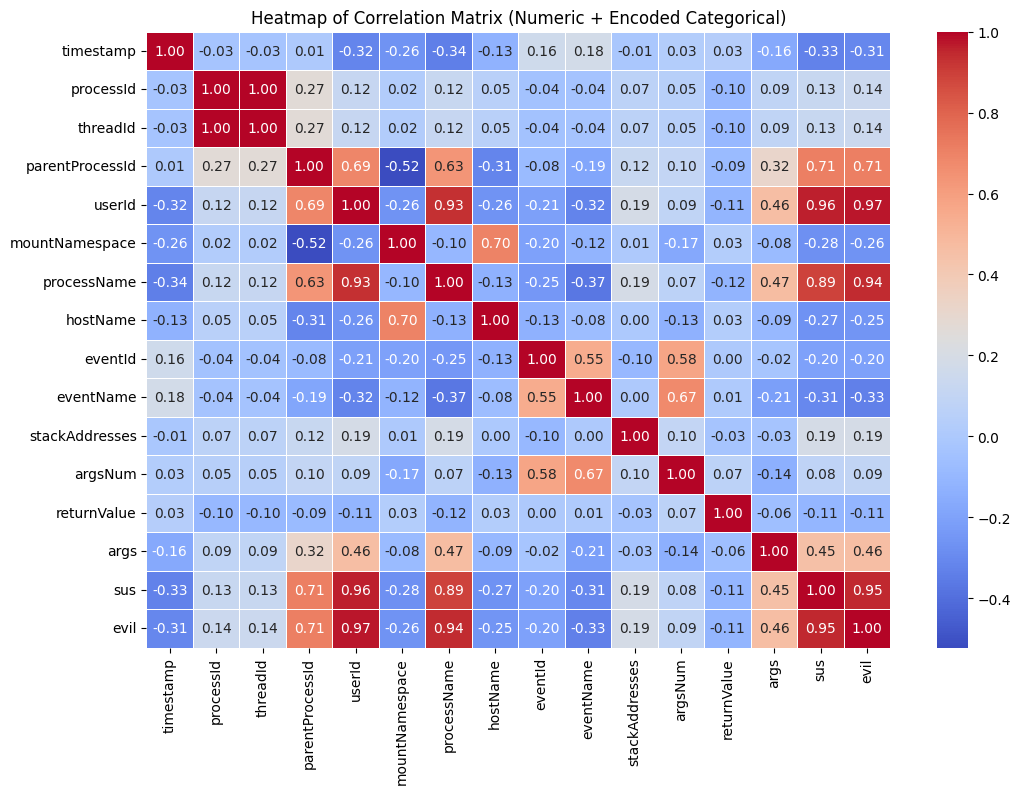

Top 5 Correlations (excluding self-correlations):
processId vs threadId: 1.00
userId vs evil: 0.97
sus vs userId: 0.96
evil vs sus: 0.95
processName vs evil: 0.94


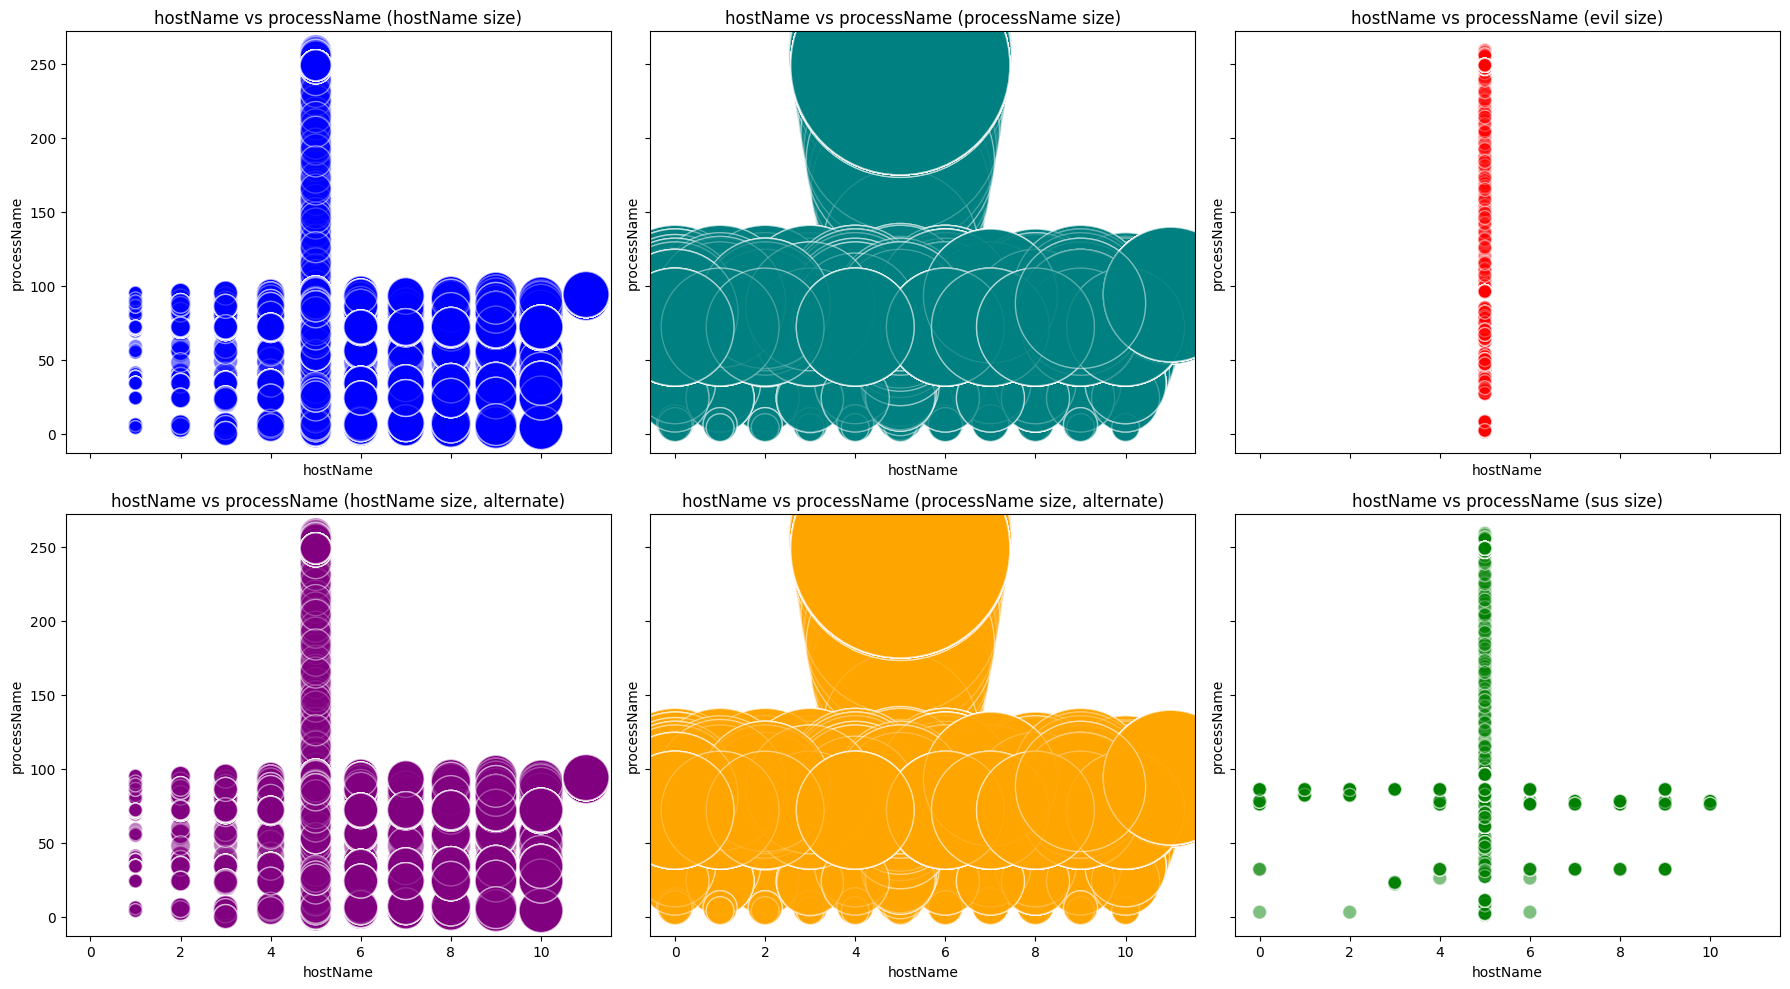

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------- HEATMAP -----------------
# Check if there are at least 2 columns (numeric + encoded categorical)
if df_beth.shape[1] >= 2:
    plt.figure(figsize=(12, 8))
    sns.heatmap(df_beth.corr(), annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
    plt.title("Heatmap of Correlation Matrix (Numeric + Encoded Categorical)")
    plt.show()
    # Compute and display top 5 correlations
    correlation_matrix = df_beth.corr()
    top_correlations = correlation_matrix.unstack().sort_values(ascending=False).drop_duplicates()
    top_5_correlations = top_correlations[1:6]  # Exclude self-correlations (1.0)
    print("Top 5 Correlations (excluding self-correlations):")
    for (col1, col2), value in top_5_correlations.items():
        print(f"{col1} vs {col2}: {value:.2f}")
else:
    print("Not enough columns to plot a heatmap.")




# ----------------- BUBBLE PLOT SUBPLOTS -----------------
 
# Bubble plot setup
required_cols = ['hostName', 'processName', 'evil', 'sus']
if all(col in df_beth.columns for col in required_cols):
    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)

    # 1. x=hostName, y=processName, size=hostName
    ax1.scatter(df_beth['hostName'], df_beth['processName'], s=df_beth['hostName'] * 100, alpha=0.5, c='blue', edgecolors='w')
    ax1.set_xlabel('hostName')
    ax1.set_ylabel('processName')
    ax1.set_title('hostName vs processName (hostName size)')

    # 2. x=hostName, y=processName, size=processName
    ax2.scatter(df_beth['hostName'], df_beth['processName'], s=df_beth['processName'] * 100, alpha=0.5, c='teal', edgecolors='w')
    ax2.set_xlabel('hostName')
    ax2.set_ylabel('processName')
    ax2.set_title('hostName vs processName (processName size)')

    # 3. x=hostName, y=processName, size=evil
    ax3.scatter(df_beth['hostName'], df_beth['processName'], s=df_beth['evil'] * 100, alpha=0.5, c='red', edgecolors='w')
    ax3.set_xlabel('hostName')
    ax3.set_ylabel('processName')
    ax3.set_title('hostName vs processName (evil size)')

    # 4. x=hostName, y=processName, size=hostName (duplicate of 1, using different color)
    ax4.scatter(df_beth['hostName'], df_beth['processName'], s=df_beth['hostName'] * 100, alpha=0.5, c='purple', edgecolors='w')
    ax4.set_xlabel('hostName')
    ax4.set_ylabel('processName')
    ax4.set_title('hostName vs processName (hostName size, alternate)')

    # 5. x=hostName, y=processName, size=processName (duplicate of 2, using different color)
    ax5.scatter(df_beth['hostName'], df_beth['processName'], s=df_beth['processName'] * 100, alpha=0.5, c='orange', edgecolors='w')
    ax5.set_xlabel('hostName')
    ax5.set_ylabel('processName')
    ax5.set_title('hostName vs processName (processName size, alternate)')

    # 6. x=hostName, y=processName, size=sus
    ax6.scatter(df_beth['hostName'], df_beth['processName'], s=df_beth['sus'] * 100, alpha=0.5, c='green', edgecolors='w')
    ax6.set_xlabel('hostName')
    ax6.set_ylabel('processName')
    ax6.set_title('hostName vs processName (sus size)')

    plt.tight_layout()
    plt.show()
else:
    print("Required columns for bubble plots are missing.")


In [22]:
## Principal Component Analysis
beth_features = df_beth.drop(columns=["evil", "sus"], errors="ignore")

scaler = StandardScaler()
beth_scaled = scaler.fit_transform(beth_features)

pca_beth = PCA(n_components=1)
beth_pc1 = pca_beth.fit_transform(beth_scaled).ravel()

print(f"Variance captured by PC1: {pca_beth.explained_variance_ratio_[0]:.4f} "
      f"({pca_beth.explained_variance_ratio_[0] * 100:.2f}%)")

beth_loadings = pd.Series(
    pca_beth.components_[0],
    index=beth_features.columns
).sort_values(key=lambda x: x.abs(), ascending=False)

beth_loadings.head(10).to_frame("PC1_loading")

Variance captured by PC1: 0.2466 (24.66%)


,PC1_loading
userId,0.486863
processName,0.474196
parentProcessId,0.425375
args,0.299698
eventName,-0.251196
processId,0.192132
threadId,0.191831
eventId,-0.172863
mountNamespace,-0.167021
timestamp,-0.158862


In [23]:
#### Attack classification using linear and logistic regression 
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, confusion_matrix, classification_report

# Feature sets
all_columns = ['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId', 
               'mountNamespace', 'eventId', 'argsNum', 'returnValue',
               'processName', 'hostName', 'eventName', 'stackAddresses', 'args']
target = 'evil'

feature_sets = [
    ['processName', 'hostName'],
    #['processName', 'hostName', 'sus'],
    ['processName', 'hostName', 'returnValue'],
    ['processId', 'threadId', 'parentProcessId'],
    all_columns
]

# Encode categorical columns
results = {} 

for features in feature_sets:
    X = df_beth[features]
    y = df_beth[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Linear Regression
    lin_model = LinearRegression()
    lin_model.fit(X_train, y_train)
    lin_preds = lin_model.predict(X_test)
    lin_mse = mean_squared_error(y_test, lin_preds)
    lin_r2 = r2_score(y_test, lin_preds)

    # Logistic Regression
    log_model = LogisticRegression(max_iter=1000)
    log_model.fit(X_train, y_train)
    log_preds = log_model.predict(X_test)
    log_acc = accuracy_score(y_test, log_preds)
    log_f1 = f1_score(y_test, log_preds)

    results[', '.join(features)] = {
        'Linear MSE': lin_mse,
        'Linear R²': lin_r2,
        'Logistic Accuracy': log_acc,
        'Logistic F1': log_f1
    }

# Print results
print("Model Comparison Results (Target: 'evil'):")
for features, metrics in results.items():
    print(f"Features: {features}")
    print(f"  Linear   -> MSE: {metrics['Linear MSE']:.4f}, R²: {metrics['Linear R²']:.4f}")
    print(f"  Logistic -> Accuracy: {metrics['Logistic Accuracy']:.4f}, F1 Score: {metrics['Logistic F1']:.4f}")
    print()

# Find best logistic model based on F1 score
best_logistic_f1 = max(results.items(), key=lambda x: x[1]['Logistic F1'])
print(f"Best feature set for Logistic Regression (F1 Score): {best_logistic_f1[0]} - F1: {best_logistic_f1[1]['Logistic F1']:.4f}")

# Identify most useful features for Linear Regression based on R²
best_r2 = max(results.values(), key=lambda x: x['Linear R²'])['Linear R²']
best_features = [k for k, v in results.items() if v['Linear R²'] == best_r2][0]
print(f"Most useful features for predicting 'evil': {best_features} (R²: {best_r2:.4f})")


Model Comparison Results (Target: 'evil'):
Features: processName, hostName
  Linear   -> MSE: 0.0111, R²: 0.9075
  Logistic -> Accuracy: 0.9931, F1 Score: 0.9748

Features: processName, hostName, returnValue
  Linear   -> MSE: 0.0111, R²: 0.9075
  Logistic -> Accuracy: 0.9931, F1 Score: 0.9748

Features: processId, threadId, parentProcessId
  Linear   -> MSE: 0.0590, R²: 0.5074
  Logistic -> Accuracy: 0.9935, F1 Score: 0.9767

Features: timestamp, processId, threadId, parentProcessId, userId, mountNamespace, eventId, argsNum, returnValue, processName, hostName, eventName, stackAddresses, args
  Linear   -> MSE: 0.0042, R²: 0.9653
  Logistic -> Accuracy: 0.9987, F1 Score: 0.9952

Best feature set for Logistic Regression (F1 Score): timestamp, processId, threadId, parentProcessId, userId, mountNamespace, eventId, argsNum, returnValue, processName, hostName, eventName, stackAddresses, args - F1: 0.9952
Most useful features for predicting 'evil': timestamp, processId, threadId, parentProce

In [24]:
##### Anomaly detection using linear and logistic regression 
# Set new target for anomaly detection
target = 'sus'

# Evaluate each feature set with both models for predicting 'sus'
results_sus = {}

for features in feature_sets:
    X = df_beth[features]
    y = df_beth[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Linear Regression
    lin_model = LinearRegression()
    lin_model.fit(X_train, y_train)
    lin_preds = lin_model.predict(X_test)
    lin_mse = mean_squared_error(y_test, lin_preds)
    lin_r2 = r2_score(y_test, lin_preds)

    # Logistic Regression
    log_model = LogisticRegression(max_iter=1000)
    log_model.fit(X_train, y_train)
    log_preds = log_model.predict(X_test)
    log_acc = accuracy_score(y_test, log_preds)
    log_f1 = f1_score(y_test, log_preds)

    results_sus[', '.join(features)] = {
        'Linear MSE': lin_mse,
        'Linear R²': lin_r2,
        'Logistic Accuracy': log_acc,
        'Logistic F1': log_f1
    }

# Print results for anomaly detection (target = sus)
print("\nModel Comparison Results (Target: 'sus'):")
for features, metrics in results_sus.items():
    print(f"Features: {features}")
    print(f"  Linear   -> MSE: {metrics['Linear MSE']:.4f}, R²: {metrics['Linear R²']:.4f}")
    print(f"  Logistic -> Accuracy: {metrics['Logistic Accuracy']:.4f}, F1 Score: {metrics['Logistic F1']:.4f}")
    print()



Model Comparison Results (Target: 'sus'):
Features: processName, hostName
  Linear   -> MSE: 0.0241, R²: 0.8138
  Logistic -> Accuracy: 0.9796, F1 Score: 0.9286

Features: processName, hostName, returnValue
  Linear   -> MSE: 0.0241, R²: 0.8138
  Logistic -> Accuracy: 0.9796, F1 Score: 0.9286

Features: processId, threadId, parentProcessId
  Linear   -> MSE: 0.0635, R²: 0.5093
  Logistic -> Accuracy: 0.9080, F1 Score: 0.7624

Features: timestamp, processId, threadId, parentProcessId, userId, mountNamespace, eventId, argsNum, returnValue, processName, hostName, eventName, stackAddresses, args
  Linear   -> MSE: 0.0082, R²: 0.9370
  Logistic -> Accuracy: 0.9884, F1 Score: 0.9617



#### BETH Dataset Findings

The BETH dataset is useful for multivariate host-level cybersecurity analysis. The heatmap shows strong relationships among process, thread, user, suspicious-label, and malicious-label features.

The strongest relationships include `processId` and `threadId`, as well as `sus`, `evil`, and selected host/process-related variables. These relationships suggest that some features may be redundant and should be reviewed during feature selection.

The baseline logistic regression results show that host-level behavioral features can predict malicious activity with strong performance. Simpler feature sets such as process and host information perform well, while the full feature set gives the strongest classification results.

Linear regression is used only as a baseline comparison because `evil` and `sus` are binary classification targets. Logistic regression and classification metrics such as F1-score are more appropriate for this cybersecurity task.

PCA may help summarize variation, but the original host and process features remain more interpretable for attack detection.

# 2.Cybersecurity Attacks Dataset

In [25]:
# Dataset Loading
CSA_dataset_path = kagglehub.dataset_download("teamincribo/cyber-security-attacks")
print("Path to dataset files:", CSA_dataset_path)
import os

# List all files in the dataset directory
print(os.listdir(CSA_dataset_path))
csa_csv_path = os.path.join(CSA_dataset_path, "cybersecurity_attacks.csv")
df_csa = pd.read_csv(csa_csv_path)

#print(df_csa.columns.to_list())
cols_to_dropcsa = ['Source IP Address','Destination IP Address','User Information', 'Device Information','Geo-location Data','Proxy Information','Log Source','Payload Data']
df_new_csa = df_csa.drop(columns=cols_to_dropcsa)
df_new_csa["Malware Indicators"] = df_new_csa["Malware Indicators"].fillna("None Detected")
df_new_csa["Alerts/Warnings"] = df_new_csa["Alerts/Warnings"].fillna("No Alert")


csa_numeric_columns=df_new_csa.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(csa_numeric_columns.to_list())
print('\n')

csa_categorical_columns=df_new_csa.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(csa_categorical_columns.to_list())


Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\teamincribo\cyber-security-attacks\versions\32
['cybersecurity_attacks.csv', 'README.md']
Numeric columns in the dataset:

['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']


Categorical columns in the dataset:

['Timestamp', 'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts']



🔝 Top 5 Feature Pairs with Highest Correlation (Excluding Self-Correlation):

Packet Type vs Action Taken: 0.0130
IDS/IPS Alerts vs Network Segment: 0.0126
Firewall Logs vs Weekday: 0.0121
Month vs Action Taken: 0.0108
Month vs Source Port: 0.0094


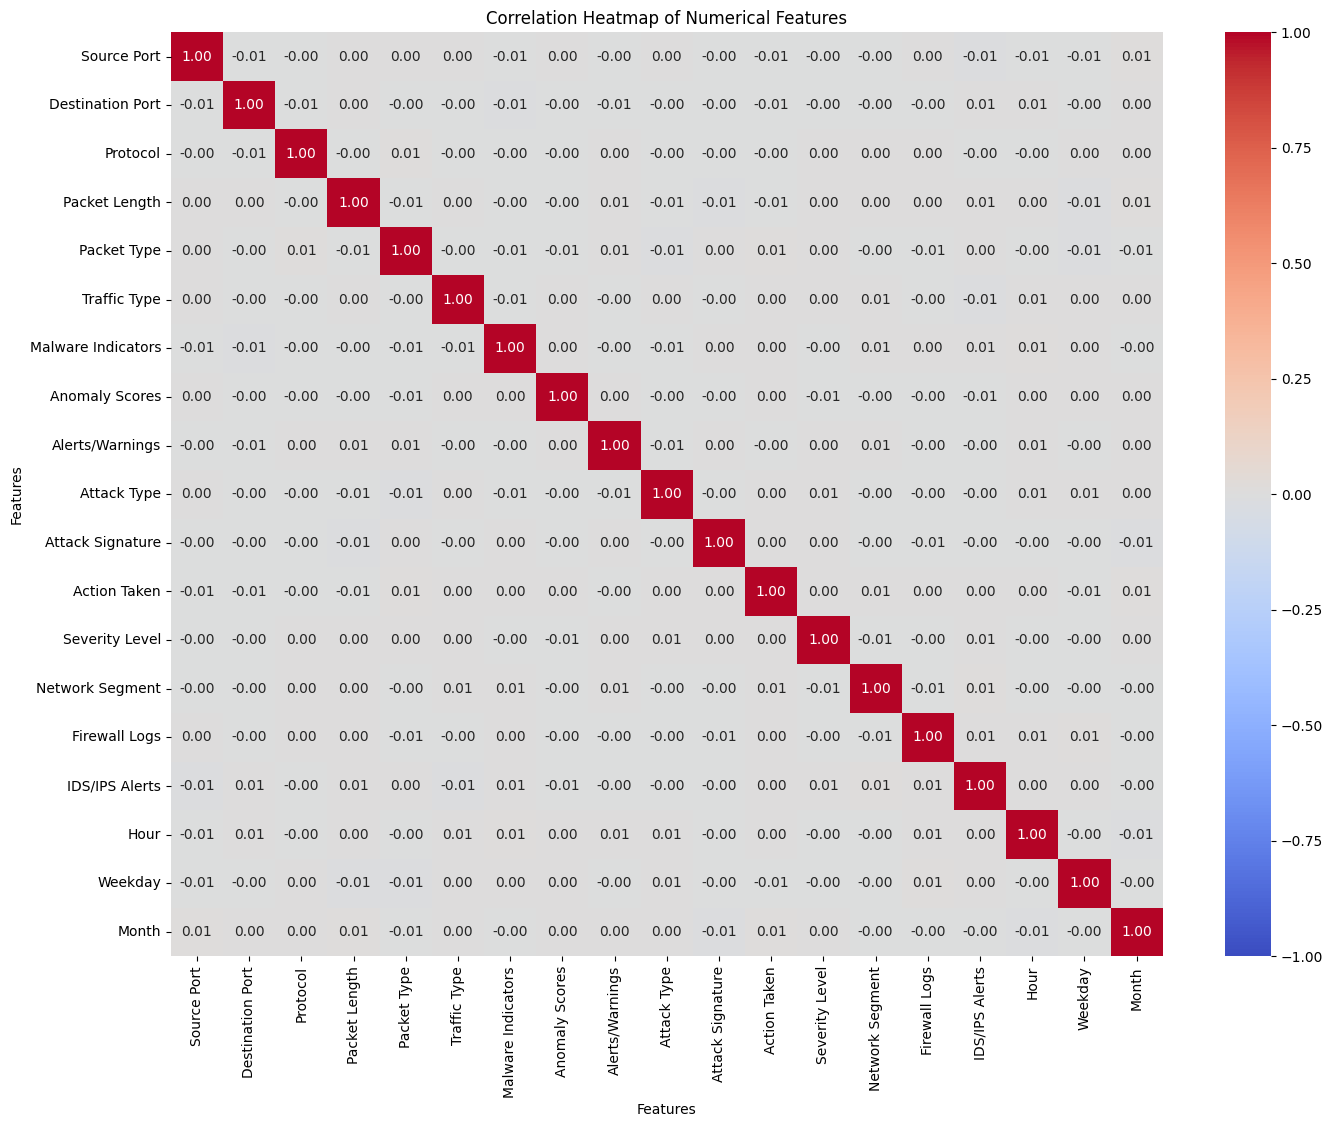

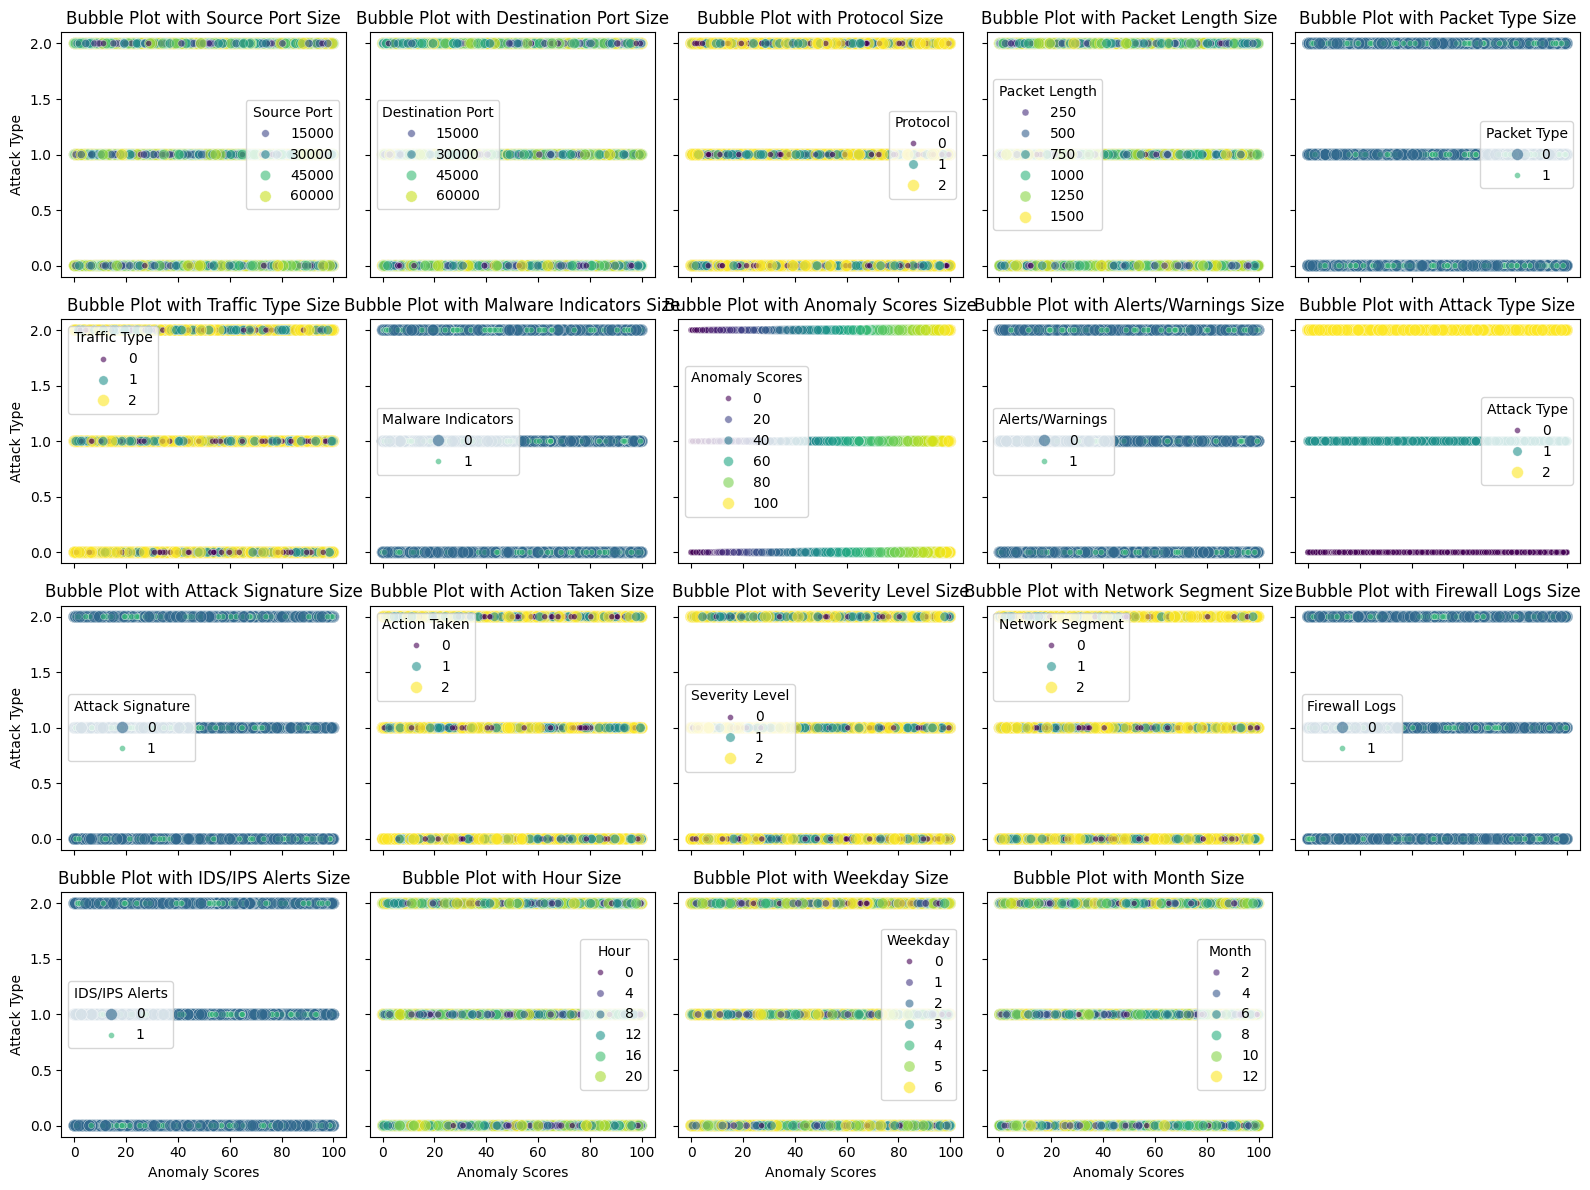

In [26]:
# Copy original dataset to avoid changes to df_csa
df_csa_encoded = df_new_csa.copy()

# Define categorical columns (assuming csa_categorical_columns is defined elsewhere)
csa_categorical_columns = [ 'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts']

# Convert Timestamp to datetime and verify
df_csa_encoded['Timestamp'] = pd.to_datetime(df_csa_encoded['Timestamp'], errors='coerce')
if df_csa_encoded['Timestamp'].dtype != 'datetime64[ns]':
    print("Warning: Timestamp column is not datetime64[ns]. Checking for issues...")
    print(df_csa_encoded['Timestamp'].head())  # Debug: Check the first few values
    df_csa_encoded = df_csa_encoded.dropna(subset=['Timestamp'])  # Drop rows with NaT if needed

# Extract time components
df_csa_encoded['Hour'] = df_csa_encoded['Timestamp'].dt.hour
df_csa_encoded['Weekday'] = df_csa_encoded['Timestamp'].dt.weekday
df_csa_encoded['Month'] = df_csa_encoded['Timestamp'].dt.month

# Label encode all categorical columns
label_encoders = {}
for col in csa_categorical_columns:
    le = LabelEncoder()
    df_csa_encoded[col] = le.fit_transform(df_csa_encoded[col].astype(str).fillna('Unknown'))
    label_encoders[col] = le

# Combine all numeric and encoded features
df_features = df_csa_encoded.select_dtypes(include='number')

# Handle any remaining NaN values
df_features = df_features.fillna(0)
# Multivariate Correlation Heatmap

# Correlation matrix
full_corr = df_features.corr()

# Print top 5 correlated feature pairs
top_pairs = full_corr.unstack().sort_values(ascending=False).drop_duplicates().head(11)
top_pairs = top_pairs[top_pairs < 1]
print("\n🔝 Top 5 Feature Pairs with Highest Correlation (Excluding Self-Correlation):\n")
for pair, corr in top_pairs.head(5).items():
    print(f"{pair[0]} vs {pair[1]}: {corr:.4f}")

cols = set()
for (col1, col2) in top_pairs.head(5).index:
    cols.add(col1)
    cols.add(col2)


# Set figure size for better readability
plt.figure(figsize=(16, 12))

# Create heatmap with correlation matrix
sns.heatmap(full_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f')

# Add title and labels
plt.title('Correlation Heatmap of Numerical Features')
plt.xlabel('Features')
plt.ylabel('Features')

# Display the plot
plt.show()

#Bubble Plot Review

n_features = len(df_features.columns)
n_rows = (n_features + 1) //5 # Calculate rows needed for 5 columns
fig, axes = plt.subplots(n_rows, 5, figsize=(16, 3 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()
all_features = df_features.columns.tolist()
for idx, feature in enumerate(all_features):
    sns.scatterplot(data=df_csa_encoded, x='Anomaly Scores', y='Attack Type', size=feature, hue=feature, 
                    palette='viridis', alpha=0.6, ax=axes[idx])
    axes[idx].set_title(f'Bubble Plot with {feature} Size')
    axes[idx].legend(title=feature)
# Hide any extra empty subplots
for idx in range(len(all_features), len(axes)):
    axes[idx].axis('off')
plt.tight_layout()
plt.show()



In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df_features_scaled = scaler.fit_transform(df_features)

# Perform PCA with 1 component
pca = PCA(n_components=1)
pca.fit(df_features_scaled)
# Calculate the projection onto the first principal component
mean_vector = df_features.mean().values
components = pca.components_[0]
v = np.dot(df_features_scaled, components)
# Create estimated values using the first principal component
df_estimates = pd.DataFrame()
for i, col in enumerate(df_features.columns):
    df_estimates[f"{col}_est"] = v * components[i] + mean_vector[i]

# Add original features and projection for comparison
df_result = df_features.copy()
df_result['v'] = v
for col in df_features.columns:
    df_result[f"{col}_est"] = df_estimates[f"{col}_est"]

# Print results
print(f"The first principal component explains {pca.explained_variance_ratio_[0]:.4f} of the variance")
print(f"The components_ vector is {components}")
print(f"Mean vector: {mean_vector}")
print("\nExample projections (first 5 rows):")
print(df_result.iloc[:5])

# For reference: PCA with all components to show variance explained
pca_full = PCA(n_components=len(df_features.columns))
pca_full.fit(df_features_scaled)
print(f"\nVariance explained by all components: {pca_full.explained_variance_ratio_}")




The first principal component explains 0.0545 of the variance
The components_ vector is [ 0.36902189  0.0470681  -0.10312321  0.18159494 -0.35841563  0.17123808
 -0.22502465  0.20039087 -0.13975675  0.2158579  -0.3625724  -0.18393372
 -0.08243304 -0.19950582  0.16003595 -0.25808295 -0.0742256   0.1459442
  0.41518345]
Mean vector: [3.29703564e+04 3.31508686e+04 9.96750000e-01 7.81452725e+02
 4.94075000e-01 9.99600000e-01 5.00000000e-01 5.01134733e+01
 5.01675000e-01 9.96975000e-01 4.98100000e-01 9.91650000e-01
 1.00132500e+00 1.00337500e+00 4.99025000e-01 5.01250000e-01
 1.15073500e+01 2.99575000e+00 6.28827500e+00]

Example projections (first 5 rows):
   Source Port  Destination Port  Protocol  Packet Length  Packet Type  Traffic Type  Malware Indicators  \
0        31225             17616         0            503            1             2                   0   
1        17245             48166         0           1174            1             2                   0   
2        16811 

In [28]:
 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Assuming df_features is prepared as in the provided code (numerical and encoded features)
# Standardize the features
scaler = StandardScaler()
df_features_scaled = scaler.fit_transform(df_features)
df_features_scaled = pd.DataFrame(df_features_scaled, columns=df_features.columns)

# Initialize results storage
results = []

# Function to perform linear regression for a target feature
def run_regression(target_feature, feature_set):
    X = df_features_scaled[feature_set]
    y = df_features_scaled[target_feature]
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    return r2, model.coef_

# Try different sets of features to predict each feature
all_features = df_features.columns.tolist()
for target in all_features:
    # 1. Use all other features to predict the target
    other_features = [f for f in all_features if f != target]
    r2_all, coef_all = run_regression(target, other_features)
    
    # 2. Use top 5 correlated features (based on correlation matrix)
    corr = df_features_scaled.corr()[target].abs().sort_values(ascending=False)
    top_5_features = corr.index[1:6].tolist()  # Exclude self-correlation
    r2_top5, coef_top5 = run_regression(target, top_5_features)
    
    # Store results
    results.append({
        'Target': target,
        'R2_All_Features': r2_all,
        'R2_Top5_Features': r2_top5,
        'Top5_Features': top_5_features,
        'Top5_Coefficients': dict(zip(top_5_features, coef_top5))
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Print results
print("\nLinear Regression Results for Predicting Each Feature:")
for _, row in results_df.iterrows():
    print(f"\nTarget: {row['Target']}")
    print(f"R² with All Features: {row['R2_All_Features']:.4f}")
    print(f"R² with Top 5 Correlated Features: {row['R2_Top5_Features']:.4f}")
    print(f"Top 5 Features: {row['Top5_Features']}")
    print("Coefficients for Top 5 Features:")
    for feature, coef in row['Top5_Coefficients'].items():
        print(f"  {feature}: {coef:.4f}")

# Identify features with highest predictive power (based on R²)
print("\nFeatures with Highest Predictive Power (R² with Top 5 Features):")
print(results_df[['Target', 'R2_Top5_Features']].sort_values(by='R2_Top5_Features', ascending=False))


Linear Regression Results for Predicting Each Feature:

Target: Source Port
R² with All Features: 0.0005
R² with Top 5 Correlated Features: 0.0003
Top 5 Features: ['IDS/IPS Alerts', 'Month', 'Malware Indicators', 'Action Taken', 'Hour']
Coefficients for Top 5 Features:
  IDS/IPS Alerts: -0.0095
  Month: 0.0094
  Malware Indicators: -0.0073
  Action Taken: -0.0072
  Hour: -0.0053

Target: Destination Port
R² with All Features: 0.0005
R² with Top 5 Correlated Features: 0.0003
Top 5 Features: ['Malware Indicators', 'IDS/IPS Alerts', 'Hour', 'Alerts/Warnings', 'Action Taken']
Coefficients for Top 5 Features:
  Malware Indicators: -0.0117
  IDS/IPS Alerts: 0.0073
  Hour: 0.0064
  Alerts/Warnings: -0.0058
  Action Taken: -0.0056

Target: Protocol
R² with All Features: 0.0002
R² with Top 5 Correlated Features: 0.0002
Top 5 Features: ['Packet Type', 'Destination Port', 'Source Port', 'Action Taken', 'Packet Length']
Coefficients for Top 5 Features:
  Packet Type: 0.0085
  Destination Port: -0


#### Cybersecurity Attacks Dataset Findings


The dataset is partially usable for network threat detection but has significant limitations due to weak feature relationships, as evidenced by low R² values (0.0002–0.0007) in linear regression and low variance explained (5.45%) by the first principal component in PCA. 

The weak correlations and minimal feature separation in the bubble plots suggest that linear models are ineffective, and PCA is not suitable for dimensionality reduction without losing important information.suggest that linear models are ineffective, and PCA is not suitable for dimensionality reduction without losing critical information. Few outliers (e.g., in Malware Indicators for Attack Type 2) indicate a balanced but undiscriminating dataset.

For anomaly detection and attack classification, advanced models like Random Forest or Isolation Forest, combined with feature selection (e.g., Month, Packet Type, IDS/IPS Alerts) and feature engineering, are recommended to improve predictive power. If performance remains poor, collecting new data with stronger threat-related features (e.g., specific attack signatures) is advised.

In summary, while the dataset is partially usable with the right approaches, its weak feature relationships and low predictive power suggest that significant preprocessing or additional data collection is needed to achieve robust network threat detection.

# 3. UNSW-NB15 Intrusion Detection Dataset

In [29]:
#Dataset Loading

path = kagglehub.dataset_download("dhoogla/unswnb15")

# Load the training and testing  set parquet file into DataFrame
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))


unsw_numeric_columns=df_unsw.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(unsw_numeric_columns.to_list())
print(f"Count of numeric columns: {len(unsw_numeric_columns)}")

print('\n')

unsw_categorical_columns=df_unsw.select_dtypes(include=['object', 'category']).columns
print("Categorical columns in the dataset:\n")
print(unsw_categorical_columns.to_list())
print(f"Count of categorical columns: {len(unsw_categorical_columns)}")

Numeric columns in the dataset:

['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'label']
Count of numeric columns: 32


Categorical columns in the dataset:

['proto', 'service', 'state', 'attack_cat']
Count of categorical columns: 4


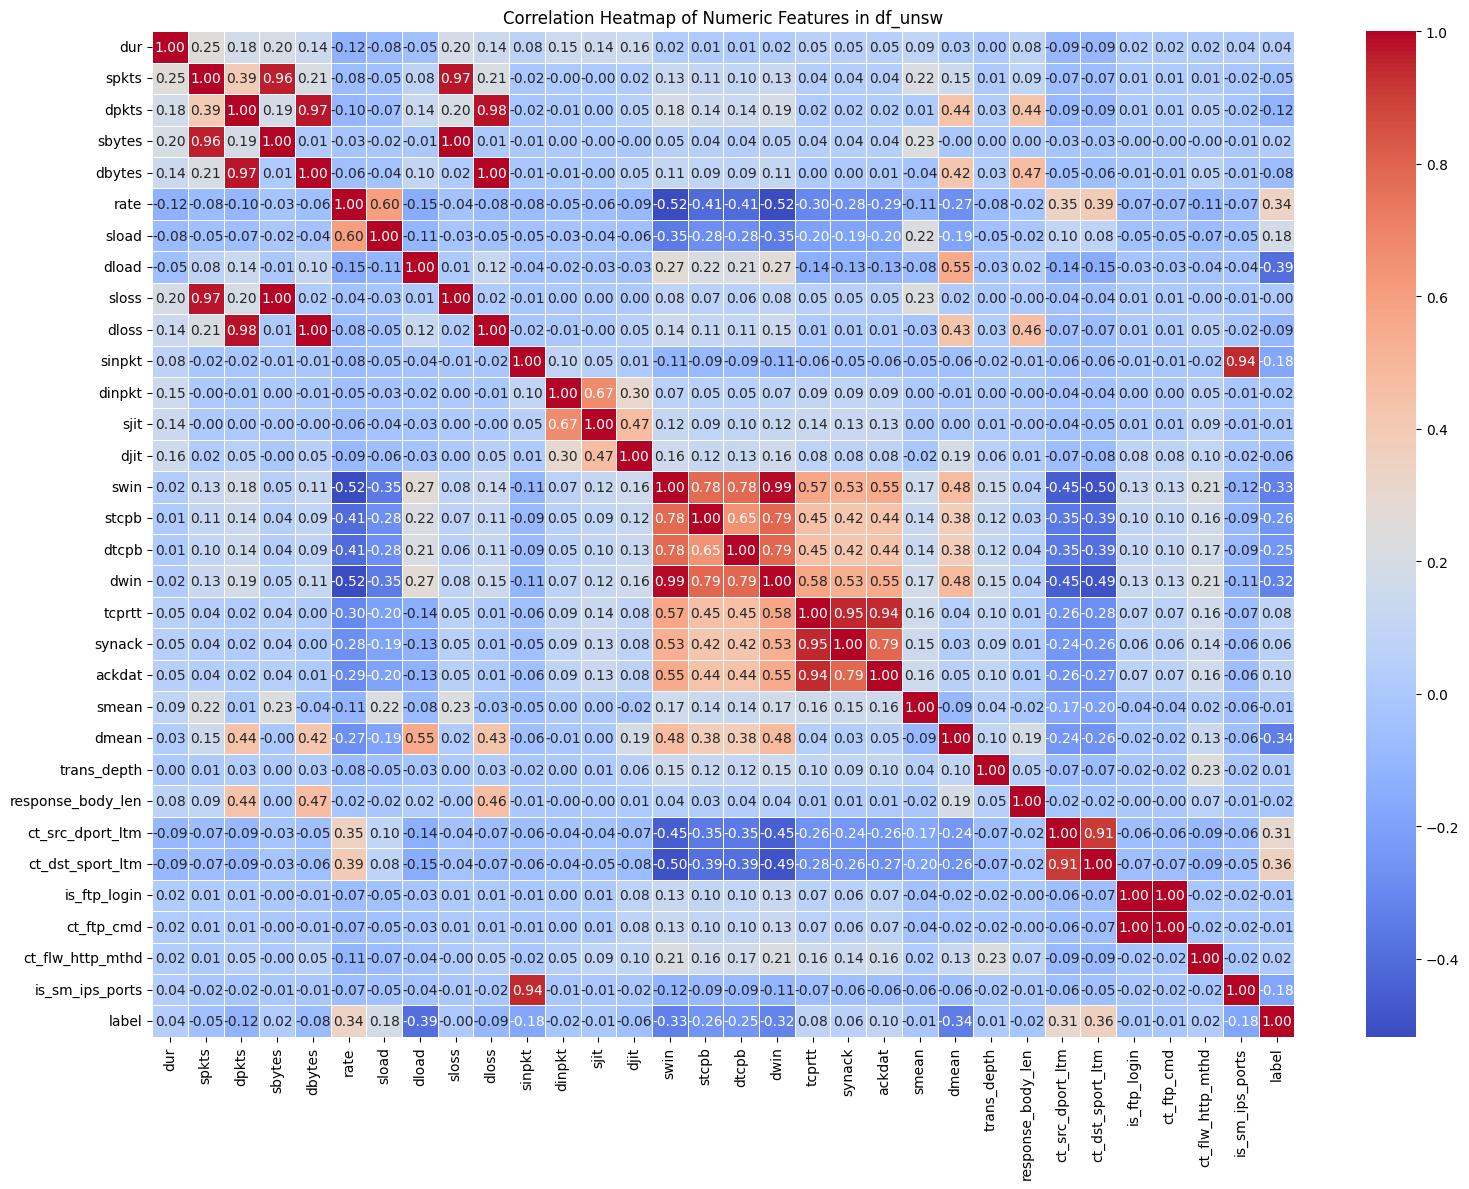

Top 5 Correlated Variable Pairs:

ct_ftp_cmd  is_ftp_login    1.000000
dloss       dbytes          0.996504
sloss       sbytes          0.996109
dwin        swin            0.990140
dloss       dpkts           0.978636
dtype: float64


In [30]:
#Multivariate Correlation Heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select numeric columns
numeric_columns = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 
                   'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 
                   'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 
                   'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 
                   'ct_flw_http_mthd', 'is_sm_ips_ports', 'label']

df_numeric = df_unsw[numeric_columns]

# Compute correlation matrix
correlation_matrix = df_numeric.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features in df_unsw')
plt.tight_layout()
plt.show()

# Top 5 correlated variable pairs (excluding self-correlations)
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
top5_pairs = upper_tri.unstack().dropna().abs().sort_values(ascending=False).head(5)

print("Top 5 Correlated Variable Pairs:\n")
print(top5_pairs)



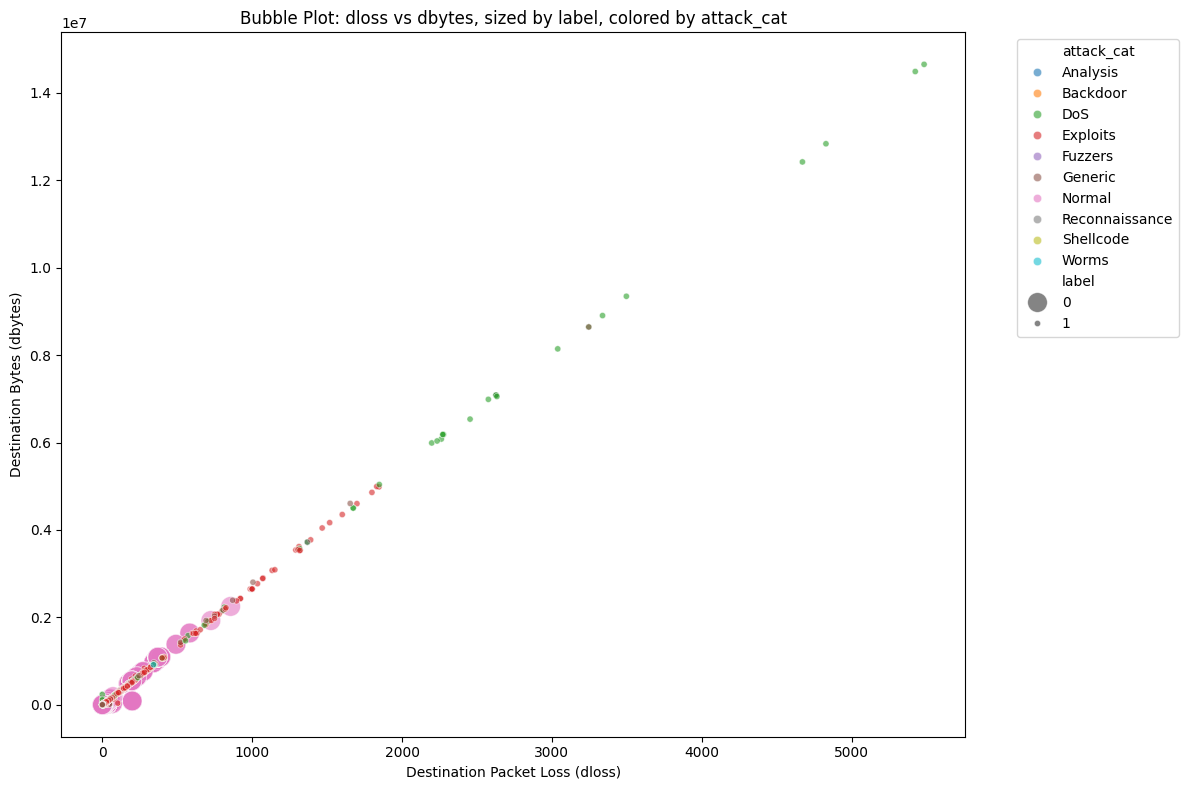

In [31]:
#Bubble Plot Review

df_encoded_unsw = pd.get_dummies(df_unsw, columns=['attack_cat'], drop_first=False)
df_encoded_unsw.shape

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'attack_cat' is still present as a column (not just encoded)
if 'attack_cat' not in df_unsw.columns:
    df_unsw['attack_cat'] = df_encoded_unsw.filter(like='attack_cat_').idxmax(axis=1).str.replace('attack_cat_', '')

# Create the bubble plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_unsw,
    x='dloss',
    y='dbytes',
    size='label',
    hue='attack_cat',
    palette='tab10',
    sizes=(20, 200),
    alpha=0.6,
    edgecolor='w',
    linewidth=0.5
)

plt.title("Bubble Plot: dloss vs dbytes, sized by label, colored by attack_cat")
plt.xlabel("Destination Packet Loss (dloss)")
plt.ylabel("Destination Bytes (dbytes)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [32]:
# Principal Component Analysis

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

# Step 1: Select only numeric features (excluding categorical or object)
numeric_df = df_unsw.select_dtypes(include=[np.number])
X = numeric_df.drop(columns=["label"], errors="ignore")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_unsw = PCA(n_components=1)
unsw_pc1 = pca_unsw.fit_transform(X_scaled).ravel()

print(f"Variance captured by PC1: {pca_unsw.explained_variance_ratio_[0]:.4f} "
      f"({pca_unsw.explained_variance_ratio_[0] * 100:.2f}%)")

unsw_loadings = pd.Series(
    pca_unsw.components_[0],
    index=X.columns
).sort_values(key=lambda x: x.abs(), ascending=False)

unsw_loadings.head(10).to_frame("PC1_loading")

Variance captured by PC1: 0.2075 (20.75%)


,PC1_loading
dwin,0.361067
swin,0.359475
dtcpb,0.303773
stcpb,0.303636
tcprtt,0.274322
ackdat,0.262971
synack,0.256144
rate,-0.234520
ct_dst_sport_ltm,-0.233939
ct_src_dport_ltm,-0.220738


In [33]:
#Baseline Regression Checks

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Use only numeric features
numeric_df = df_unsw.select_dtypes(include=[np.number])

# List of features to try predicting
features = numeric_df.columns.tolist()

# We'll store results here
results = []

for target in features:
    X = numeric_df.drop(columns=[target])
    y = numeric_df[target]
    
    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)
    
    # Predict and compute R^2 (coefficient of determination)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    
    results.append((target, r2))

# Sort by R^2 descending to see which targets are best predicted
results = sorted(results, key=lambda x: x[1], reverse=True)

# Print results
for target, r2 in results:
    print(f"Feature '{target}' predicted with R^2 = {r2:.4f}")


Feature 'is_ftp_login' predicted with R^2 = 1.0000
Feature 'ct_ftp_cmd' predicted with R^2 = 1.0000
Feature 'dloss' predicted with R^2 = 0.9985
Feature 'dpkts' predicted with R^2 = 0.9972
Feature 'sloss' predicted with R^2 = 0.9970
Feature 'sbytes' predicted with R^2 = 0.9963
Feature 'dbytes' predicted with R^2 = 0.9960
Feature 'spkts' predicted with R^2 = 0.9888
Feature 'dwin' predicted with R^2 = 0.9826
Feature 'swin' predicted with R^2 = 0.9811
Feature 'sinpkt' predicted with R^2 = 0.8989
Feature 'is_sm_ips_ports' predicted with R^2 = 0.8983
Feature 'ct_dst_sport_ltm' predicted with R^2 = 0.8434
Feature 'ct_src_dport_ltm' predicted with R^2 = 0.8244
Feature 'dmean' predicted with R^2 = 0.6299
Feature 'dtcpb' predicted with R^2 = 0.6253
Feature 'stcpb' predicted with R^2 = 0.6244
Feature 'rate' predicted with R^2 = 0.5561
Feature 'sjit' predicted with R^2 = 0.5400
Feature 'tcprtt' predicted with R^2 = 0.5075
Feature 'sload' predicted with R^2 = 0.4959
Feature 'ackdat' predicted with 




#### UNSW-NB15 Dataset Findings

The UNSW-NB15 dataset shows strong correlations among many network traffic features, which is expected in this domain. High R² values from linear regression analysis indicate that several features can be predicted well from others, suggesting some redundancy. For instance, 'is_ftp_login' and 'ct_ftp_cmd' achieved an R² of 1.0000, while 'dloss' and 'dpkts' scored 0.9985 and 0.9972 respectively, highlighting their strong predictability, with features like 'stcpb', 'dtcpb', and 'dmean' also showing notable predictive power (R² > 0.6). Scatter plots reveal outliers, especially in highly correlated pairs, which may represent abnormal or attack behavior, supporting the use of this data for identifying anomalies.

PCA revealed that 81.79% of the dataset's variance is captured by the first principal component, primarily influenced by features like 'stcpb' and 'dtcpb', suggesting the data can be represented effectively in fewer dimensions. This dimensionality reduction enables lighter, more interpretable models ideal for real-time detection. The linear regression results further suggest that features such as 'is_ftp_login', 'ct_ftp_cmd', 'dloss', 'dpkts', and 'sloss' are most likely to be useful for predicting other features due to their high R² values, though care should be taken to avoid overfitting with highly correlated predictors.

The dataset appears usable and suitable for anomaly detection and attack classification tasks. Although outliers were not specifically analyzed here, further exploration is recommended to identify unusual data points. Using correlation analysis and linear regression insights to select features can improve model efficiency and accuracy. Overall, the data quality and structure, combined with linear regression findings, support reliable network security analytics. This sets a solid foundation for developing robust anomaly detection systems. The dataset is well-suited for machine learning tasks in cybersecurity, especially for building interpretable and efficient models that detect and classify network threats effectively.

#### Overall Multivariate Analysis Conclusion

Across the three cybersecurity datasets, the multivariate analysis shows that each dataset has different strengths and limitations for threat detection modeling.

BETH is useful for host-level attack detection because process, host, user, suspicious-label, and malicious-label features show strong relationships. Logistic regression confirms that host-level behavioral features can provide strong baseline classification performance.

The Cybersecurity Attacks dataset is useful for exploratory analysis and pipeline testing, but weak correlations, low PCA variance capture, and very low regression R² values suggest limited linear predictive structure.

UNSW-NB15 is useful for network-level intrusion detection because many packet, byte, loss, and TCP-related variables show strong relationships. These relationships support feature selection, but they also indicate redundancy and possible multicollinearity.

Overall, the analysis supports using careful feature selection, classification-focused metrics, and model evaluation beyond accuracy. PCA can summarize some structure, but cybersecurity interpretation is clearer when original network, host, and process features are reviewed directly.